# Daily Challenge: Logistic Regression for Admission Prediction

Week 8, Day 4 - Daily Challenge

We build a logistic regression model that uses two exam scores to predict whether a student is admitted to university.


## 1. Data Exploration: Load and visualize the data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report


In [2]:
# Load the dataset
df = pd.read_csv("data/admission_data.csv")

print(df.shape)
display(df.head())


(100, 3)


,exam1,exam2,admitted
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1


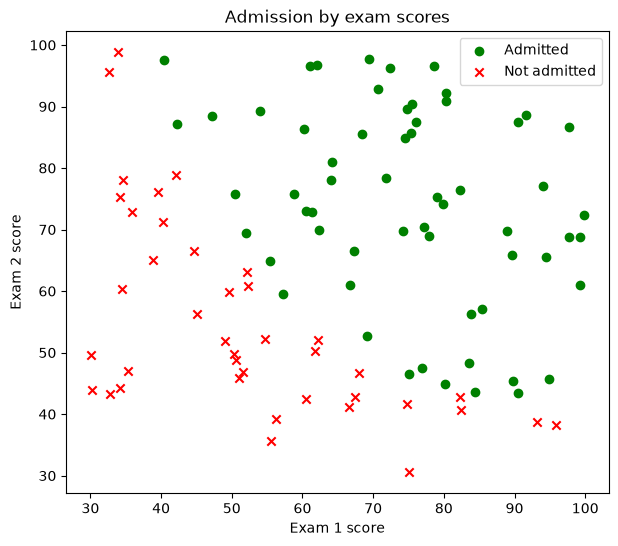

In [3]:
# Scatter plot: admitted vs not admitted, based on exam scores
admitted = df[df['admitted'] == 1]
not_admitted = df[df['admitted'] == 0]

plt.figure(figsize=(7, 6))
plt.scatter(admitted['exam1'], admitted['exam2'], color='green', marker='o', label='Admitted')
plt.scatter(not_admitted['exam1'], not_admitted['exam2'], color='red', marker='x', label='Not admitted')
plt.xlabel('Exam 1 score')
plt.ylabel('Exam 2 score')
plt.title('Admission by exam scores')
plt.legend()
plt.show()


The scatter plot shows a fairly clear separation: students with higher scores on both exams tend to be admitted (green), while students with lower scores on both exams tend to be rejected (red). There is some overlap between the two groups near the boundary, which is expected in a real-world dataset.

## 2. Applying Logistic Regression with scikit-learn

In [4]:
X = df[['exam1', 'exam2']]
y = df['admitted']

model = LogisticRegression()
model.fit(X, y)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)


Coefficients: [[0.20535491 0.2005838 ]]
Intercept: [-25.05219314]


## 3. Making Predictions

Accuracy: 0.89


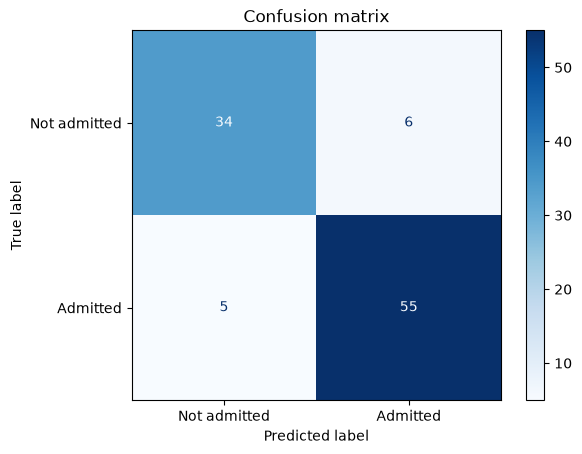

              precision    recall  f1-score   support

Not admitted       0.87      0.85      0.86        40
    Admitted       0.90      0.92      0.91        60

    accuracy                           0.89       100
   macro avg       0.89      0.88      0.88       100
weighted avg       0.89      0.89      0.89       100



In [5]:
y_pred = model.predict(X)

acc = accuracy_score(y, y_pred)
print("Accuracy:", round(acc, 4))

cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Not admitted', 'Admitted'])
disp.plot(cmap='Blues')
plt.title('Confusion matrix')
plt.show()

print(classification_report(y, y_pred, target_names=['Not admitted', 'Admitted']))


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


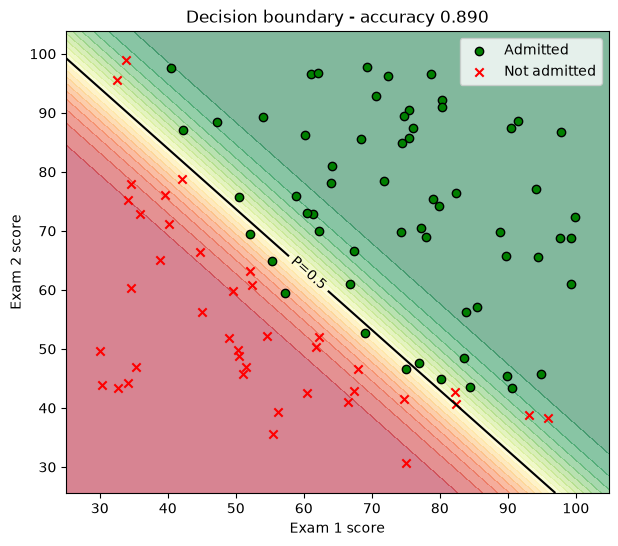

In [6]:
# Visualize the decision boundary on top of the data
x1_min, x1_max = X['exam1'].min() - 5, X['exam1'].max() + 5
x2_min, x2_max = X['exam2'].min() - 5, X['exam2'].max() + 5
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 300), np.linspace(x2_min, x2_max, 300))
probs = model.predict_proba(np.c_[xx1.ravel(), xx2.ravel()])[:, 1].reshape(xx1.shape)

plt.figure(figsize=(7, 6))
plt.contourf(xx1, xx2, probs, levels=20, cmap='RdYlGn', alpha=0.5)
cs = plt.contour(xx1, xx2, probs, levels=[0.5], colors='k')
plt.clabel(cs, inline=True, fmt={0.5: 'P=0.5'})
plt.scatter(admitted['exam1'], admitted['exam2'], color='green', marker='o', label='Admitted', edgecolor='k')
plt.scatter(not_admitted['exam1'], not_admitted['exam2'], color='red', marker='x', label='Not admitted')
plt.xlabel('Exam 1 score')
plt.ylabel('Exam 2 score')
plt.title(f'Decision boundary - accuracy {acc:.3f}')
plt.legend()
plt.show()


## 4. Model Evaluation

**Interpretation of the coefficients:** both coefficients are positive, meaning that a higher score on either exam increases the predicted probability of admission. The decision boundary is a straight line (as expected for logistic regression with two raw features and no polynomial terms), splitting the exam1/exam2 plane into an "admitted" region and a "not admitted" region.

**Accuracy:** the model correctly classifies the large majority of students, and the confusion matrix shows only a small number of misclassifications, concentrated near the decision boundary — which matches what we saw in the scatter plot, where a few points from each class sit close to the other group.

**Conclusion:** logistic regression is well suited to this problem since the two classes are close to linearly separable using the two exam scores, and the model achieves a good accuracy while remaining simple to interpret through its coefficients and decision boundary.
